In [1]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import sys
import re
from tqdm import tqdm
import pandas as pd

# import some tools from the wider directory
sys.path.insert(0, os.path.abspath('..'))   # adds fastersimulation/ to the path
import utilities
path = "../results/sphere_sweep/"
out_path = os.path.join(path, "combined_sweep.h5")
collate=False

In [2]:
if collate:
    def _parse_folder(folder_name):
        """
        i90.0_raan135.0_omega0.0
        """
        m = re.search(
            r"^i([^_]+)_raan([^_]+)_omega([^_]+)$",
            folder_name
        )
        if m:
            try:
                return (
                    float(m.group(1)),  # i
                    float(m.group(2)),  # raan
                    float(m.group(3)),  # omega
                )
            except ValueError:
                pass
        return -1.0, -1.0, -1.0

    # Discover all simulation folders
    sweep_dirs = [
        d for d in os.listdir(path)
        if os.path.isdir(os.path.join(path, d)) and d.startswith("i")
    ]

    # Sort hierarchically by calkp, calkd, obskp, obskd, ki
    sweep_dirs.sort(key=lambda d: _parse_folder(d))

    out_path = os.path.join(path, "combined_sweep.h5")
    missing = []

    print(f"Collating {len(sweep_dirs)} folders into {out_path}...")

    with h5py.File(out_path, "w") as out_f:
        for folder in tqdm(sweep_dirs):
            i, raan, omega = _parse_folder(folder)

            if i < 0:
                print(f"  [SKIP] {folder} — could not parse parameters")
                continue

            h5_path = os.path.join(path, folder, "mirror_states.h5")
            if not os.path.isfile(h5_path):
                print(f"  [SKIP] i={i}, raan={raan}, omega={omega} — mirror_states.h5 not found")
                missing.append(folder)
                continue

            group_name = f"i={i}, raan={raan}, omega={omega}"

            with h5py.File(h5_path, "r") as src_f:
                dst_grp = out_f.create_group(group_name)
                for key in src_f.keys():
                    src_f.copy(key, dst_grp, name=key)

    print(f"\nSaved combined file → {out_path}")
    if missing:
        print(f"WARNING: {len(missing)} folders had no mirror_states.h5 file!")


In [3]:
def _h5_tree(item, indent=0, max_seg=2, first_only=False):
    """Recursively print an HDF5 tree, optionally only the first root group."""
    prefix = "  " * indent

    def _parse_root_group(name):
        if not name.startswith("a_"):
            return (-1.0, -1.0, -1.0, -1.0)
        parts = name.split("_")
        try:
            return (
                float(parts[1]),
                float(parts[3]),
                float(parts[5]),
                float(parts[7]),
            )
        except (IndexError, ValueError):
            return (-1.0, -1.0, -1.0, -1.0)

    def _segment_index(name):
        try:
            return int(name.split("_")[1])
        except (IndexError, ValueError):
            return -1

    if isinstance(item, h5py.File):
        print(f"{prefix}/ (attrs: {dict(item.attrs)})")

        children = sorted(item.keys(), key=_parse_root_group)

        if first_only and children:
            _h5_tree(item[children[0]], indent + 1, max_seg, first_only)
        else:
            for k in children:
                _h5_tree(item[k], indent + 1, max_seg, first_only)

    elif isinstance(item, h5py.Group):
        name = item.name.split("/")[-1]
        children = list(item.keys())

        seg_keys = sorted(
            [k for k in children if k.startswith("segment_")],
            key=_segment_index
        )
        other_keys = sorted(
            [k for k in children if not k.startswith("segment_")]
        )

        print(f"{prefix}┣ {name}/")

        for k in other_keys:
            _h5_tree(item[k], indent + 1, max_seg, first_only)

        for k in seg_keys[:max_seg]:
            _h5_tree(item[k], indent + 1, max_seg, first_only)

        if len(seg_keys) > max_seg:
            print(f"{'  ' * (indent + 1)}┆ ... ({len(seg_keys) - max_seg} more segment_ groups)")

    elif isinstance(item, h5py.Dataset):
        name = item.name.split("/")[-1]
        print(f"{prefix}┃  {name:30s}  {str(item.shape):20s}  {item.dtype}")


# ── Execute ──
with h5py.File(out_path, "r") as f:
    _h5_tree(f, max_seg=1, first_only=True)

/ (attrs: {})
  ┣ i=0.0, raan=0.0, omega=0.0/
    ┣ config/
      ┃  star_vector                     (3,)                  float64
    ┃  dv                              (513920,)             float64
    ┃  dv_xyz                          (513920, 3)           float64
    ┃  mirror_time                     (90000,)              float64
    ┃  phase                           (513920,)             object
    ┃  r_app_eci                       (513920, 3)           float64
    ┃  r_det_eci                       (513920, 3)           float64
    ┃  rel_pos_B                       (90000, 3)            float64
    ┃  rel_sigma_B                     (513920, 3)           float64
    ┃  sigma_app_star                  (513920, 3)           float64
    ┃  sigma_det_star                  (513920, 3)           float64
    ┃  time                            (513920,)             float64
    ┣ segment_0/
      ┃  desired_mirror_actuation        (90000, 6)            float64
      ┃  mirror_actuati

In [4]:
import h5py
import re
import numpy as np
from tqdm import tqdm

def _parse_grp(x):
    """
    Parse group names like: i=90.0, raan=135.0, omega=0.0
    """
    m = re.search(
        r"^i=([^,]+),\s*raan=([^,]+),\s*omega=([^,]+)$",
        x
    )
    if m:
        try:
            return (
                float(m.group(1)),  # i
                float(m.group(2)),  # raan
                float(m.group(3)),  # omega
            )
        except ValueError:
            pass
    return (-1.0, -1.0, -1.0)

def _get_ds(run_grp, name):
    """Helper to check both root and config sub-group for a dataset."""
    if "config" in run_grp and name in run_grp["config"]:
        return run_grp["config"][name][:]
    if name in run_grp:
        return run_grp[name][:]
    raise KeyError(f"Dataset '{name}' not found in '{run_grp.name}' or its config/group")

with h5py.File(out_path, "r") as src_f:
    # 1. Identify and sort simulation runs
    group_keys = sorted(
        [k for k in src_f.keys() if k.startswith("i=")],
        key=_parse_grp
    )

    num_runs = len(group_keys)
    print(f"Total number of simulation runs = {num_runs}")

    if num_runs == 0:
        raise ValueError("No simulation groups found in the HDF5 file.")

    # 2. Initialize storage containers
    # Global/Run-level data
    phase, full_times, eng_times = [], [], []
    i_vals, raan_vals, omega_vals = [], [], []
    r_app_eci, r_det_eci, rel_pos_B = [], [], []
    dv, dv_xyz = [], []

    # Segment-level data (Lists of lists: [run][segment])
    all_mirror_actuation = []
    all_desired_mirror_actuation = []
    all_point_on_det_plane = []

    # 3. Main processing loop
    for group in tqdm(group_keys, desc="Processing Simulations"):
        run_grp = src_f[group]
        i, raan, omega = _parse_grp(group)

        # Store parameters
        i_vals.append(i)
        raan_vals.append(raan)
        omega_vals.append(omega)

        # Store run-level arrays
        phase_arr = _get_ds(run_grp, "phase")
        phase.append(np.array(phase_arr, dtype=str))
        full_times.append(_get_ds(run_grp, "time"))
        eng_times.append(_get_ds(run_grp, "mirror_time"))
        r_app_eci.append(_get_ds(run_grp, "r_app_eci"))
        r_det_eci.append(_get_ds(run_grp, "r_det_eci"))
        rel_pos_B.append(_get_ds(run_grp, "rel_pos_B"))

        # Handle dv and dv_xyz logic
        if "config" in run_grp and "dv" in run_grp["config"]:
            dv.append(run_grp["config"]["dv"][:])
        elif "dv" in run_grp:
            dv.append(run_grp["dv"][:])

        if "config" in run_grp and "dv_xyz" in run_grp["config"]:
            dv_xyz.append(run_grp["config"]["dv_xyz"][:])
        elif "dv_xyz" in run_grp:
            dv_xyz.append(run_grp["dv_xyz"][:])

        # 4. Handle Nested Segments (segment_0, segment_1, etc.)
        # Sort keys to ensure segment sequence is preserved
        segment_keys = sorted([k for k in run_grp.keys() if k.startswith("segment_")])
        
        run_mirror = []
        run_desired_mirror = []
        run_det_plane = []

        for seg_key in segment_keys:
            seg_grp = run_grp[seg_key]
            run_mirror.append(seg_grp["mirror_actuation"][:])
            run_desired_mirror.append(seg_grp["desired_mirror_actuation"][:])
            run_det_plane.append(seg_grp["point_on_det_plane"][:])

        all_mirror_actuation.append(run_mirror)
        all_desired_mirror_actuation.append(run_desired_mirror)
        all_point_on_det_plane.append(run_det_plane)

print("\nData successfully loaded!")
print(f"Loaded {len(all_mirror_actuation)} runs, each containing {len(all_mirror_actuation[0])} segments.")

Total number of simulation runs = 144


Processing Simulations: 100%|██████████| 144/144 [04:39<00:00,  1.94s/it]


Data successfully loaded!
Loaded 144 runs, each containing 7 segments.


  0%|          | 0/1 [00:00<?, ?it/s]

Highlighted runs:
Run 6: i=0.0, raan=135.0, omega=0.0


100%|██████████| 1/1 [00:23<00:00, 23.11s/it]


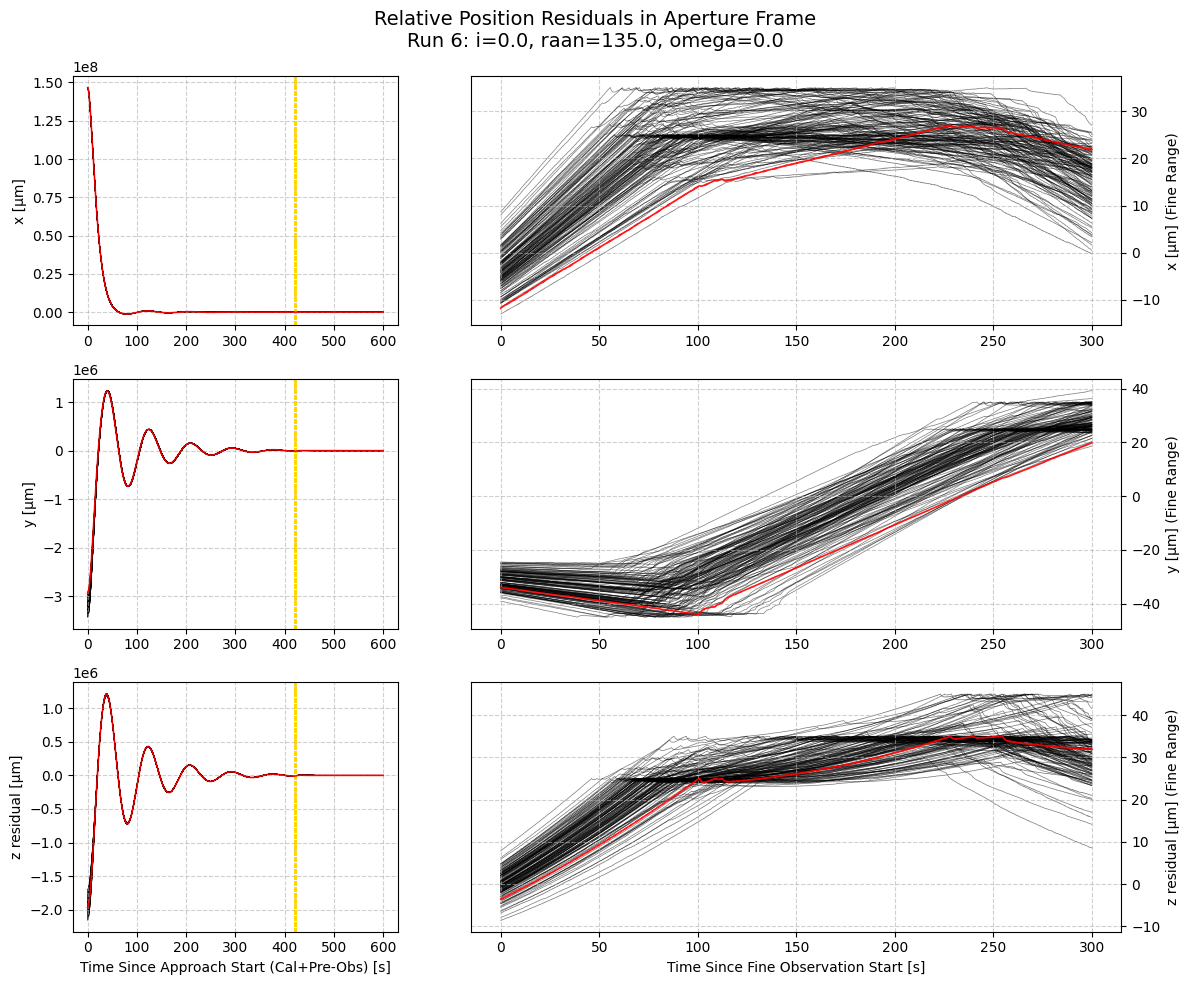

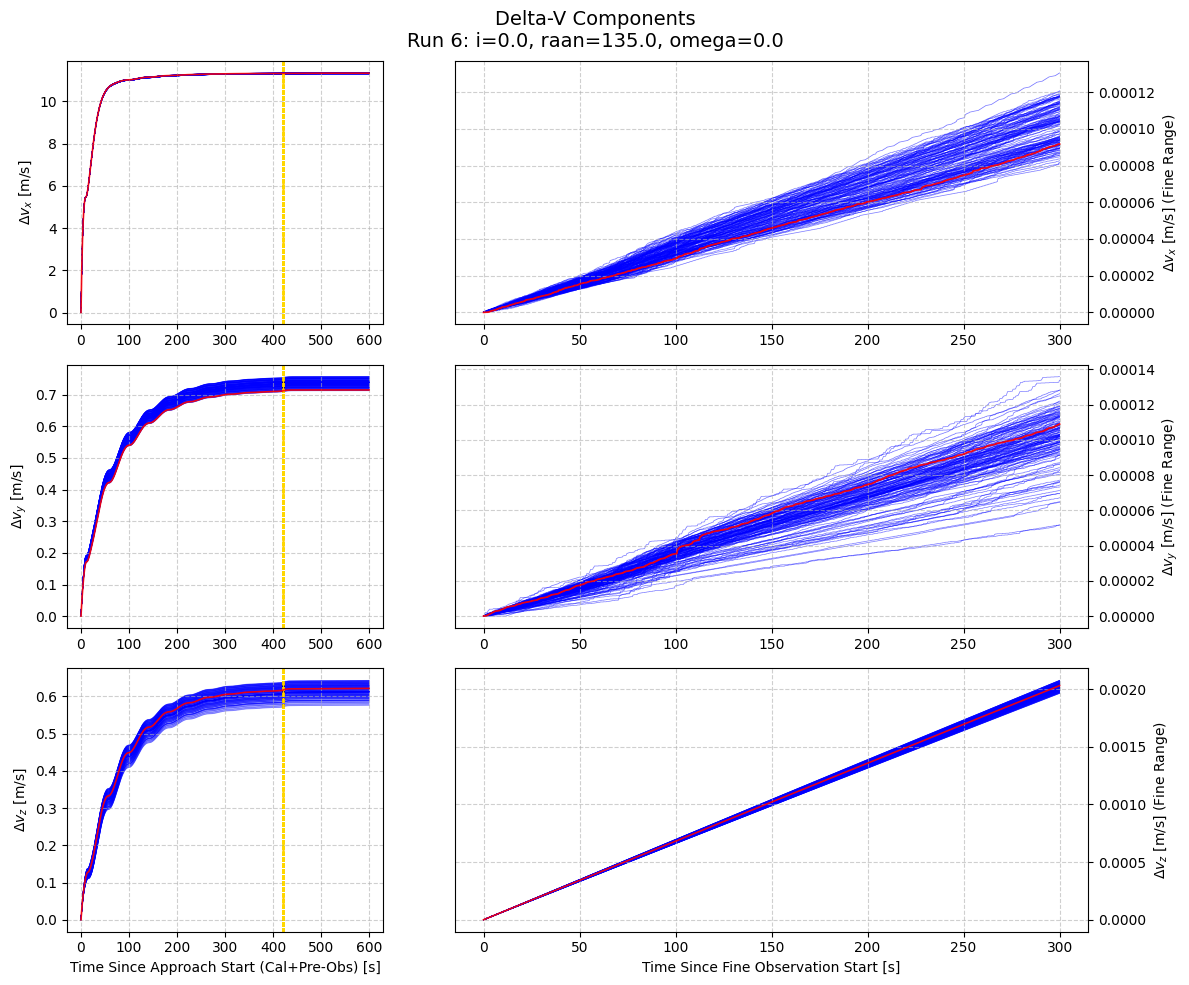

In [5]:
coord_letter = ["x", "y", "z"]

alpha_lines   = 0.5
current_focal = 5000.0

for highlight_runs in tqdm([6]):

    highlight_runs = {highlight_runs}
    
    # Print the highlighted parameter combinations once, before plotting
    print("Highlighted runs:")
    for i in sorted(highlight_runs):
        highlight_text = f"Run {i}: i={i_vals[i]}, raan={raan_vals[i]}, omega={omega_vals[i]}"
        print(highlight_text)
    
    rel_pos_fig = plt.figure(figsize=(12, 10))
    gs = gridspec.GridSpec(3, 2, width_ratios=[1, 2], figure=rel_pos_fig)
    rel_pos_fig.suptitle(f"Relative Position Residuals in Aperture Frame\n{highlight_text}", fontsize=14)
    
    rel_pos_ax = []
    for row in range(3):
        ax_approach = rel_pos_fig.add_subplot(gs[row, 0])
        ax_fine     = rel_pos_fig.add_subplot(gs[row, 1])
        ax_fine.yaxis.tick_right()
        ax_fine.yaxis.set_label_position("right")
        rel_pos_ax.append((ax_approach, ax_fine))
    
    rel_pos_ax[2][0].set_xlabel("Time Since Approach Start (Cal+Pre-Obs) [s]")
    rel_pos_ax[2][1].set_xlabel("Time Since Fine Observation Start [s]")
    
    for coord in range(3):
        label = coord_letter[coord]
        if coord == 2:
            label = "z residual"
        rel_pos_ax[coord][0].set_ylabel(f"{label} [µm]")
        rel_pos_ax[coord][1].set_ylabel(f"{label} [µm] (Fine Range)")
        rel_pos_ax[coord][0].grid(True, linestyle="--", alpha=0.6)
        rel_pos_ax[coord][1].grid(True, linestyle="--", alpha=0.6)
    
    for i in range(len(phase)):
        t_full  = full_times[i]
        t_eng   = eng_times[i]
        rel     = rel_pos_B[i]
        phase_i = np.array(phase[i], dtype=str)
    
        cal_idx     = np.where(phase_i == "Calibration")[0]
        pre_obs_idx = np.where(phase_i == "Pre-Observation")[0]
        fine_idx    = np.where(phase_i == "Fine Observation")[0]
    
        approach_indices = np.concatenate([cal_idx, pre_obs_idx])
        if len(approach_indices) > 0:
            t_approach_start = t_full[approach_indices[0]]
            t_approach_end   = t_full[approach_indices[-1]]
            approach_mask    = (t_eng >= t_approach_start) & (t_eng <= t_approach_end)
        else:
            approach_mask = np.zeros_like(t_eng, dtype=bool)
    
        if len(fine_idx) > 0:
            t_fine_start = t_full[fine_idx[0]]
            t_fine_end   = t_full[fine_idx[-1]]
            fine_mask    = (t_eng >= t_fine_start) & (t_eng <= t_fine_end)
        else:
            fine_mask = np.zeros_like(t_eng, dtype=bool)
    
        app_t    = t_eng[approach_mask]
        app_rel  = rel[approach_mask]
        fine_t   = t_eng[fine_mask]
        fine_rel = rel[fine_mask]
    
        if len(app_t) > 0:
            app_t = app_t - app_t[0]
        if len(fine_t) > 0:
            fine_t = fine_t - fine_t[0]
    
        if len(pre_obs_idx) > 0 and len(approach_indices) > 0:
            pre_obs_t_start = t_full[pre_obs_idx[0]] - t_full[approach_indices[0]]
            for coord in range(3):
                rel_pos_ax[coord][0].axvline(
                    pre_obs_t_start, color="gold",
                    lw=0.8, ls="--", alpha=0.7,
                    label="Pre-Obs start" if i == 0 else None
                )
    
        if i in highlight_runs:
            color = "red"
            lw = 1.2
            alpha = 0.9
            zorder = 3
        else:
            color = "k"
            lw = 0.5
            alpha = alpha_lines
            zorder = 1
    
        for coord in range(3):
            scale = 1e6  # m → µm
    
            if coord == 2:
                app_vals  = (app_rel[:, coord] - current_focal) * scale if len(app_rel) > 0 else np.array([])
                fine_vals = (fine_rel[:, coord] - current_focal) * scale if len(fine_rel) > 0 else np.array([])
            else:
                app_vals  = app_rel[:, coord] * scale if len(app_rel) > 0 else np.array([])
                fine_vals = fine_rel[:, coord] * scale if len(fine_rel) > 0 else np.array([])
    
            if len(app_t) > 0 and len(app_vals) > 0:
                rel_pos_ax[coord][0].plot(
                    app_t, app_vals,
                    lw=lw, color=color, alpha=alpha, zorder=zorder
                )
    
            if len(fine_t) > 0 and len(fine_vals) > 0:
                rel_pos_ax[coord][1].plot(
                    fine_t, fine_vals,
                    lw=lw, color=color, alpha=alpha, zorder=zorder
                )
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.15)
    plt.savefig(f'../results/controller_sweep_figs/resid_{highlight_text}.png')
    #plt.close()
    
    dv_fig = plt.figure(figsize=(12, 10))
    gs = gridspec.GridSpec(3, 2, width_ratios=[1, 2], figure=dv_fig)
    dv_fig.suptitle(f"Delta-V Components\n{highlight_text}", fontsize=14)
    
    dv_ax = []
    for row in range(3):
        ax_approach = dv_fig.add_subplot(gs[row, 0])
        ax_fine     = dv_fig.add_subplot(gs[row, 1])
        ax_fine.yaxis.tick_right()
        ax_fine.yaxis.set_label_position("right")
        dv_ax.append((ax_approach, ax_fine))
    
    dv_ax[2][0].set_xlabel("Time Since Approach Start (Cal+Pre-Obs) [s]")
    dv_ax[2][1].set_xlabel("Time Since Fine Observation Start [s]")
    
    for coord in range(len(coord_letter)):
        label = coord_letter[coord]
        dv_ax[coord][0].set_ylabel(f"$\\Delta v_{label}$ [m/s]")
        dv_ax[coord][1].set_ylabel(f"$\\Delta v_{label}$ [m/s] (Fine Range)")
        dv_ax[coord][0].grid(True, linestyle="--", alpha=0.6)
        dv_ax[coord][1].grid(True, linestyle="--", alpha=0.6)
    
    for i in range(len(phase)):
        t_full  = full_times[i]
        dv_run  = dv_xyz[i]
        phase_i = np.array(phase[i], dtype=str)
    
        cal_idx     = np.where(phase_i == "Calibration")[0]
        pre_obs_idx = np.where(phase_i == "Pre-Observation")[0]
        fine_idx    = np.where(phase_i == "Fine Observation")[0]
    
        approach_indices = np.concatenate([cal_idx, pre_obs_idx])
        if len(approach_indices) > 0:
            approach_mask = (t_full >= t_full[approach_indices[0]]) & (t_full <= t_full[approach_indices[-1]])
        else:
            approach_mask = np.zeros_like(t_full, dtype=bool)
    
        if len(fine_idx) > 0:
            fine_mask = (t_full >= t_full[fine_idx[0]]) & (t_full <= t_full[fine_idx[-1]])
        else:
            fine_mask = np.zeros_like(t_full, dtype=bool)
    
        app_t   = t_full[approach_mask]
        app_dv  = dv_run[approach_mask]
        fine_t  = t_full[fine_mask]
        fine_dv = dv_run[fine_mask]
    
        if len(app_t) > 0:
            app_t = app_t - app_t[0]
        if len(fine_t) > 0:
            fine_t = fine_t - fine_t[0]
    
        if len(pre_obs_idx) > 0 and len(approach_indices) > 0:
            pre_obs_t_start = t_full[pre_obs_idx[0]] - t_full[approach_indices[0]]
            for coord in range(3):
                dv_ax[coord][0].axvline(
                    pre_obs_t_start, color="gold",
                    lw=0.8, ls="--", alpha=0.7,
                    label="Pre-Obs start" if i == 0 else None
                )
    
        if i in highlight_runs:
            color = "red"
            lw = 1.2
            alpha = 0.9
            zorder = 3
        else:
            color = "blue"
            lw = 0.5
            alpha = alpha_lines
            zorder = 1
    
        for coord in range(3):
            if len(app_t) > 0:
                dv_ax[coord][0].plot(
                    app_t, app_dv[:, coord],
                    lw=lw, color=color, alpha=alpha, zorder=zorder
                )
    
            if len(fine_t) > 0:
                dv_ax[coord][1].plot(
                    fine_t, fine_dv[:, coord] - app_dv[-1, coord],
                    lw=lw, color=color, alpha=alpha, zorder=zorder
                )
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.15)
    plt.savefig(f'../results/controller_sweep_figs/deltav_{highlight_text}.png')
    #plt.close('all')

In [6]:
rows = []

# Assuming current_focal, phase, full_times, eng_times, rel_pos_B, dv, 
# i_vals, raan_vals, and omega_vals are already defined in your workspace.

for idx in range(len(phase)):
    # Convert inputs to numpy arrays for masking
    phase_i = np.array(phase[idx], dtype=str)
    t_full = np.asarray(full_times[idx])
    t_eng = np.asarray(eng_times[idx])
    rel = np.asarray(rel_pos_B[idx])
    dv_i = np.asarray(dv[idx])

    # 1. Find the time bounds for "Fine Observation" using t_full
    fine_idx = np.where(phase_i == "Fine Observation")[0]
    if len(fine_idx) == 0:
        continue

    t_fine_start = t_full[fine_idx[0]]
    t_fine_end   = t_full[fine_idx[-1]]

    # 2. CREATE TWO MASKS:
    # Mask for engineering-rate data (rel)
    fine_mask_eng = (t_eng >= t_fine_start) & (t_eng <= t_fine_end)
    # Mask for high-rate data (dv)
    fine_mask_full = (t_full >= t_fine_start) & (t_full <= t_fine_end)

    # 3. Apply masks and validate
    if not np.any(fine_mask_eng) or not np.any(fine_mask_full):
        continue

    fine_rel = rel[fine_mask_eng]
    dv_fine_array = dv_i[fine_mask_full]

    # 4. Calculate Statistics
    rms_x = np.sqrt(np.mean(fine_rel[:, 0] ** 2))
    rms_y = np.sqrt(np.mean(fine_rel[:, 1] ** 2))
    # Note: Ensure current_focal is a scalar or matches dimensions
    rms_z = np.sqrt(np.mean((fine_rel[:, 2] - current_focal) ** 2))

    # Append to rows - using the last dv value for the table
    rows.append({
        "i": i_vals[idx],
        "raan": raan_vals[idx],
        "omega": omega_vals[idx],
        "rms_x": rms_x * 1e6,
        "rms_y": rms_y * 1e6,
        "rms_z": rms_z * 1e6,
        "dv_cal": dv_fine_array[0],
        "dv_fine": dv_fine_array[-1] - dv_fine_array[0]
    })

# Create DataFrame
summary_df = pd.DataFrame(rows)

# Helper function to generate and sort pivot tables
def create_sorted_pivot(df, value_col):
    return df.pivot_table(
        index="raan", 
        columns="i", 
        values=value_col, 
        aggfunc="mean"
    ).sort_index().sort_index(axis=1)

# Generate Tables
rms_x_table = create_sorted_pivot(summary_df, "rms_x")
rms_y_table = create_sorted_pivot(summary_df, "rms_y")
rms_z_table = create_sorted_pivot(summary_df, "rms_z")
dv_cal_table    = create_sorted_pivot(summary_df, "dv_cal")
dv_fine_table    = create_sorted_pivot(summary_df, "dv_fine")

rms_rho_table = np.sqrt((rms_x_table**2) + (rms_y_table**2))

# Display Results
print("--- RMS Results (scaled by 1e6) ---")
print("RMS X residual table:")
print(rms_x_table)

print("\nRMS Y residual table:")
print(rms_y_table)

print("\nRMS RHO residual table:")
print(rms_rho_table)
      
print("\nRMS Z residual table:")
print(rms_z_table)

print("\n--- Delta-V CAL Table ---")
print(dv_cal_table)

print("\n--- Delta-V FINE Table ---")
print(dv_fine_table)

print(f"\nTable Dimensions: {rms_x_table.shape}")
print(f"Unique i values: {len(rms_x_table.columns)}")
print(f"Unique raan values: {len(rms_x_table.index)}")

--- RMS Results (scaled by 1e6) ---
RMS X residual table:
i          0.0        22.5       45.0       67.5       90.0       112.5  \
raan                                                                      
0.0    26.354647  28.691212  23.280656  25.390130  18.811813  28.993163   
22.5   22.935084  22.749818  24.419234  28.438290  20.144240  25.709068   
45.0   20.808576  19.711388  20.857576  26.222247  24.179199  28.251469   
67.5   20.443739  24.514035  26.546722  17.933741  27.011886  22.876796   
90.0   21.666205  18.606225  15.422335  27.937429  26.419943  25.119177   
112.5  19.158763  20.163924  17.905570  21.390089  22.427724  29.926247   
135.0  18.768233  18.431924  19.236690  19.593183  20.545055  21.848221   
157.5  27.892904  22.731404  18.934686  20.425246  21.555883  26.535979   
180.0  22.778237  19.171808  17.982758  24.330336  23.761540  17.782898   
202.5  19.890352  22.846196  22.884682  25.286611  22.585021  24.695308   
225.0  26.853845  25.909262  29.016153  26

# MAPPING THE POINTING RMS PER DIRECTION

Metric RMS RHO
Min 29.111185767131968
Max 38.88987615049411
Mean 34.0276886737774
Std Dev 2.034710989882383
Peak-to-Valley 9.778690383362143
Metric RMS Z
Min 21.729652004924795
Max 34.50964022429399
Mean 27.473186332294233
Std Dev 2.6353449647717633
Peak-to-Valley 12.779988219369194


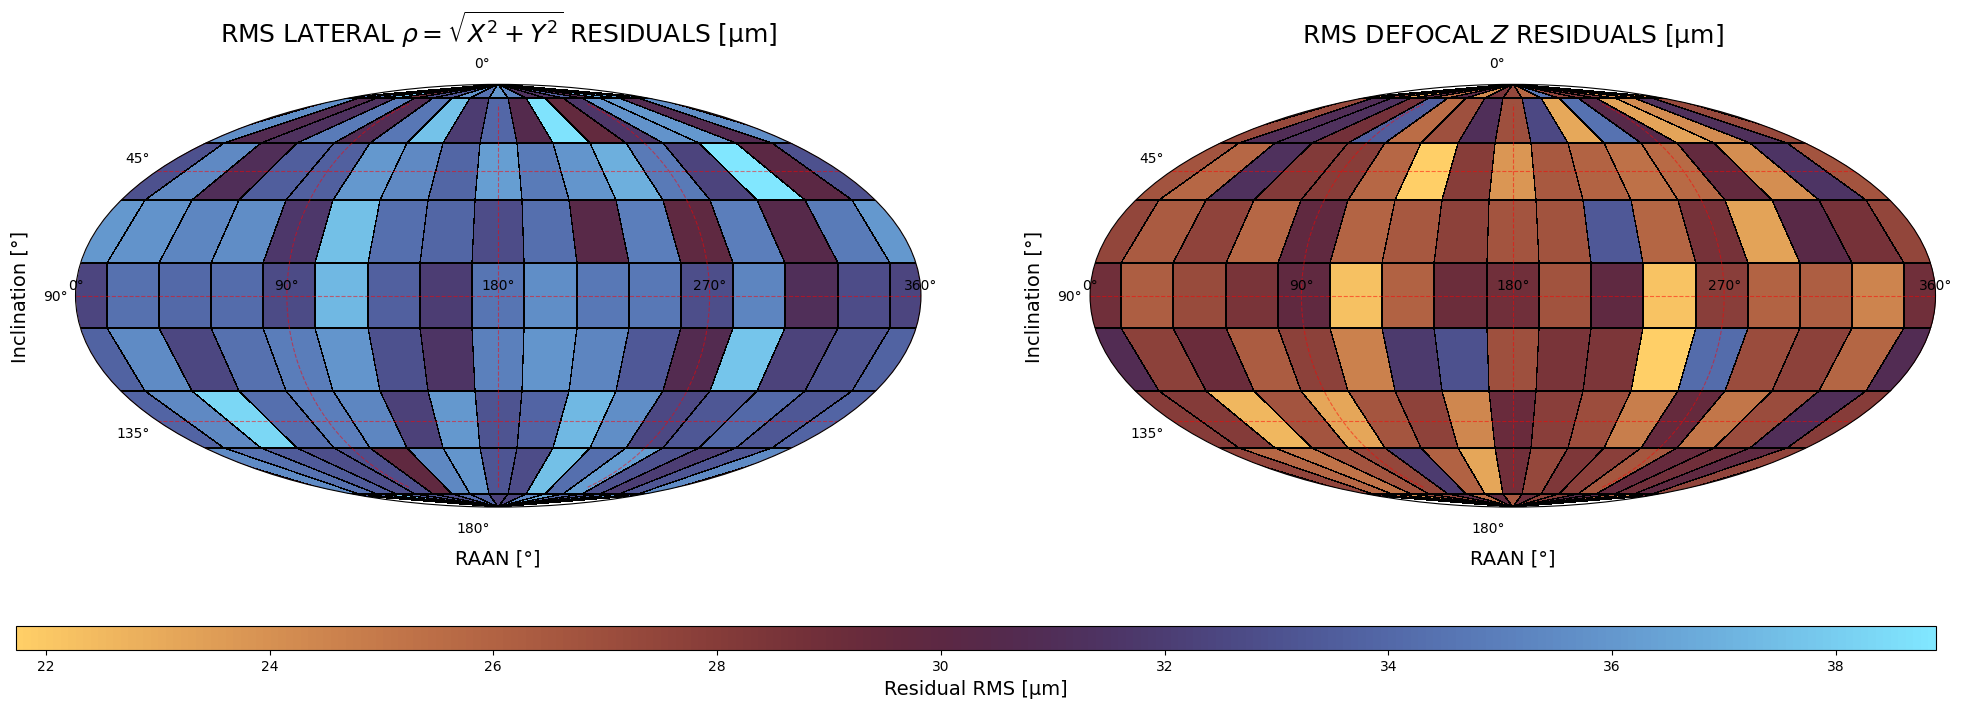

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# ==========================================
# 1. HELPER FUNCTIONS
# ==========================================
def get_data_relative_edges(centers):
    """
    Calculates edges strictly around the provided centers.
    Does not stretch to 360 or -180/180.
    """
    centers = np.sort(np.asarray(centers, dtype=float))
    if len(centers) < 2:
        return np.array([centers[0] - 0.5, centers[0] + 0.5])
        
    mids = 0.5 * (centers[:-1] + centers[1:])
    step = np.mean(np.diff(centers))
    
    # Boundary edges are exactly half a step away from the first/last point
    first = centers[0] - step/2
    last = centers[-1] + step/2
    
    return np.concatenate([[first], mids, [last]])

def plot_mollweide_strict(ax, df, title, norm, cmap="managua"):
    # 1. Ensure we only use RAAN 0 to 315
    df_plot = df[df.index <= 360.0].copy()
    # recreate data frame on other side
    df_plot.loc[360.0] = df_plot.loc[0.0]
    # 2. Coordinate Mapping
    # RAAN 0-315 -> Lon -180 to 135
    raan_centers = df_plot.index.to_numpy(dtype=float)
    lon_centers = raan_centers - 180.0
    
    # Inc 0-180 -> Lat 90 to -90
    inc_centers = df_plot.columns.to_numpy(dtype=float)
    lat_centers = 90.0 - inc_centers
    
    # 3. Create Edges (Strictly centered on data)
    lon_edges = np.deg2rad(get_data_relative_edges(lon_centers))
    lat_edges = np.deg2rad(get_data_relative_edges(lat_centers))
    
    # Safety clip for poles
    lat_edges = np.clip(lat_edges, -np.pi/2, np.pi/2)
    
    # 4. Plotting
    Z = df_plot.to_numpy().T 
    mesh = ax.pcolormesh(
        lon_edges, lat_edges, Z,
        norm=norm, cmap=cmap,
        edgecolors='black', linewidth=0.2,
        shading='flat'
    )
    
    # 5. Styling
    ax.set_title(title, pad=30, fontsize=18)
    ax.grid(True, linestyle='--', alpha=0.5, color='r')
    
    # RAAN Ticks
    ax.set_xticks(np.deg2rad([-180, -90, 0, 90, 180]))
    ax.set_xticklabels(['0°', '90°', '180°', '270°', '360°'])
    
    # Inclination Ticks
    ax.set_yticks(np.deg2rad([90, 45, 0, -45, -90]))
    ax.set_yticklabels(['0°', '45°', '90°', '135°', '180°'])
    
    return mesh

# ==========================================
# 2. EXECUTION
# ==========================================

# Assuming rms_x_table, rms_y_table, rms_z_table are your DataFrames
fig, axes = plt.subplots(1, 2, figsize=(24, 12), 
                         subplot_kw={'projection': 'mollweide'},
                         facecolor='white')

# Shared Color Scale (0 to 315 only)
all_data = pd.concat([t[t.index <= 315.0] for t in [rms_rho_table, rms_z_table]])
norm = Normalize(vmin=all_data.min().min(), vmax=all_data.max().max())

# Plot
plot_mollweide_strict(axes[0], rms_rho_table, r"RMS LATERAL $\rho = \sqrt{X^2 + Y^2}$ RESIDUALS [μm]", norm)
m = plot_mollweide_strict(axes[1], rms_z_table, r"RMS DEFOCAL $Z$ RESIDUALS [μm]", norm)

# Labels
for ax in axes:
    ax.set_xlabel("RAAN [°]", fontsize=14, labelpad=30)
    ax.set_ylabel("Inclination [°]", fontsize=14, labelpad=10)

# Colorbar Styling
fig.subplots_adjust(bottom=0.25, hspace=0.35)

cax = fig.add_axes([0.1, 0.27, 0.8, 0.02])
cb = fig.colorbar(m, cax=cax, orientation="horizontal")
cb.set_label("Residual RMS [μm]", color="k", fontsize=14)
cb.ax.yaxis.set_tick_params(color="k")
plt.setp(cb.ax.get_yticklabels(), color="k")

#plt.tight_layout()
plt.savefig(f'sphere_figs/mollweide_rms_ff.png')


#### analysis of RMS for the paper
rms_rho_table = np.sqrt(rms_x_table**2 + rms_y_table**2)

def get_stats(df, name):
    stats = {
        'Metric': name,
        'Min': df.values.min(),
        'Max': df.values.max(),
        'Mean': df.values.mean(),
        'Std Dev': df.values.std(),
        'Peak-to-Valley': df.values.max() - df.values.min()
        }
    return stats
    
print(30*'=')
rho = get_stats(rms_rho_table, r"RMS RHO")
for entry in rho:
    print(entry, rho[entry])
print(30*'=')
z = get_stats(rms_z_table, r"RMS Z")
for entry in z:
    print(entry, z[entry])

# DELTA-V HEAT MAPS

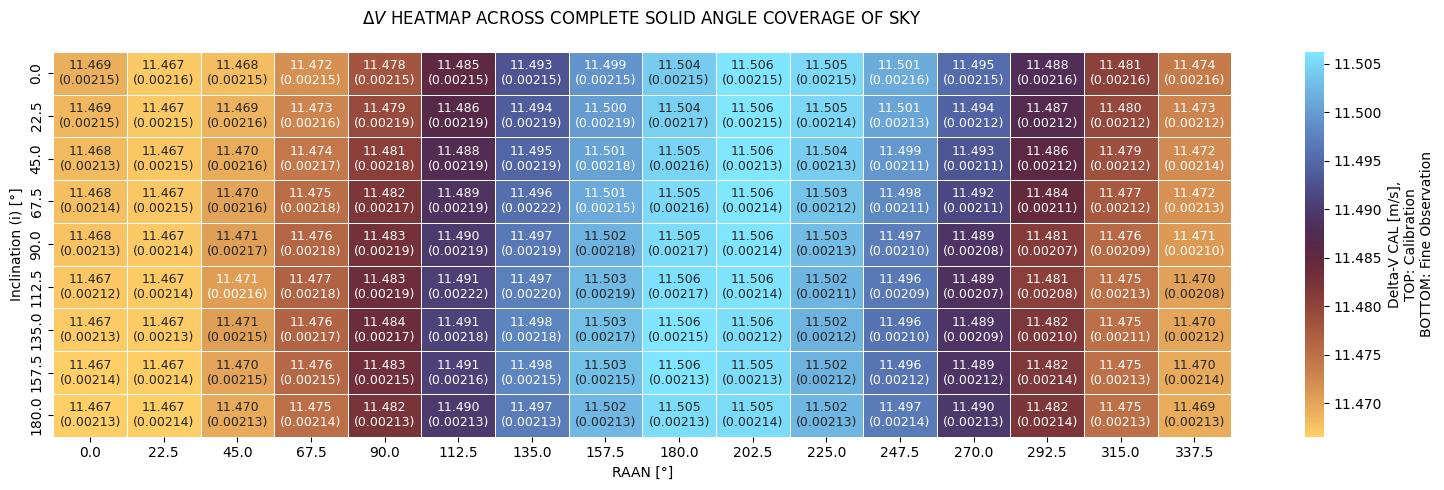

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Transpose the tables to flip the axes
# This moves 'i' to the index (y-axis) and 'raan' to the columns (x-axis)
dv_cal_table_t = dv_cal_table.T
dv_fine_table_t = dv_fine_table.T

# 2. Create the matrix of strings using the transposed tables
annot_matrix = []

for r in range(len(dv_cal_table_t)):
    row_annots = []
    for c in range(len(dv_cal_table_t.columns)):
        cal_val = dv_cal_table_t.iloc[r, c]
        fine_val = dv_fine_table_t.iloc[r, c]
        # Format: CAL on top, FINE in brackets below
        label = f"{cal_val:.3f}\n({fine_val:.5f})"
        row_annots.append(label)
    annot_matrix.append(row_annots)

annot_matrix = np.array(annot_matrix)

# 3. Plot the heatmap
plt.figure(figsize=(19, 5))

# We pass the transposed CAL table for colors and the transposed matrix for text
sns.heatmap(dv_cal_table_t, 
            annot=annot_matrix, 
            fmt="",           
            cmap="managua",      # Changed "managua" to "magma" (common typo)
            linewidths=0.5,
            linecolor='white',
            annot_kws={"fontsize": 9},
            cbar_kws={'label': 'Delta-V CAL [m/s],\nTOP: Calibration\nBOTTOM: Fine Observation'})


# 4. Title with LaTeX sizing for the top line
plt.title(r'$\Delta V$ HEATMAP ACROSS COMPLETE SOLID ANGLE COVERAGE OF SKY', pad=20)

# 5. Swap the labels to match the flip
plt.ylabel('Inclination (i) [°]')
plt.xlabel('RAAN [°]')


plt.savefig(f'sphere_figs/sphere_sweep_deltaV.png')

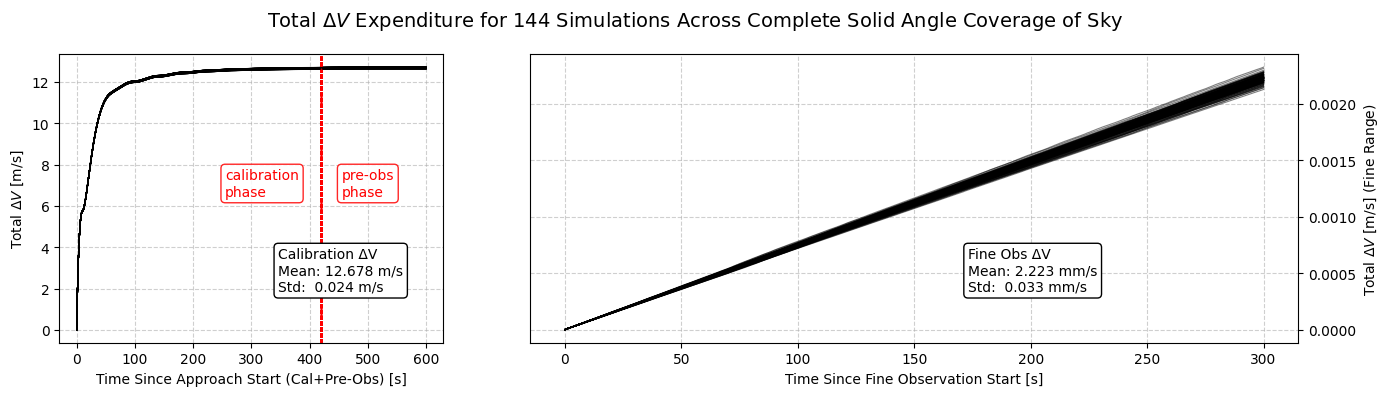

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

alpha_lines = 0.5

dv_fig = plt.figure(figsize=(14, 4))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 2], figure=dv_fig)
dv_fig.suptitle(rf"Total $\Delta V$ Expenditure for {num_runs} Simulations Across Complete Solid Angle Coverage of Sky", fontsize=14)

ax_app  = dv_fig.add_subplot(gs[0, 0])
ax_fine = dv_fig.add_subplot(gs[0, 1])

ax_fine.yaxis.tick_right()
ax_fine.yaxis.set_label_position("right")

ax_app.set_ylabel(r"Total $\Delta V$ [m/s]")
ax_fine.set_ylabel(r"Total $\Delta V$ [m/s] (Fine Range)")

ax_app.set_xlabel("Time Since Approach Start (Cal+Pre-Obs) [s]")
ax_fine.set_xlabel("Time Since Fine Observation Start [s]")

ax_app.grid(True, linestyle="--", alpha=0.6)
ax_fine.grid(True, linestyle="--", alpha=0.6)

# Collect final values for statistics
app_final_vals = []
fine_final_vals = []

for i in range(len(phase)):
    t_full = np.asarray(full_times[i])
    dv_run = np.asarray(dv_xyz[i])  # shape: (N, 3)
    phase_i = np.array(phase[i], dtype=str)

    cal_idx     = np.where(phase_i == "Calibration")[0]
    pre_obs_idx = np.where(phase_i == "Pre-Observation")[0]
    fine_idx    = np.where(phase_i == "Fine Observation")[0]

    approach_indices = np.concatenate([cal_idx, pre_obs_idx]) if (len(cal_idx) + len(pre_obs_idx)) > 0 else np.array([], dtype=int)

    if len(approach_indices) > 0:
        approach_mask = (t_full >= t_full[approach_indices[0]]) & (t_full <= t_full[approach_indices[-1]])
    else:
        approach_mask = np.zeros_like(t_full, dtype=bool)

    if len(fine_idx) > 0:
        fine_mask = (t_full >= t_full[fine_idx[0]]) & (t_full <= t_full[fine_idx[-1]])
    else:
        fine_mask = np.zeros_like(t_full, dtype=bool)

    app_t  = t_full[approach_mask]
    app_dv  = dv_run[approach_mask]
    fine_t  = t_full[fine_mask]
    fine_dv = dv_run[fine_mask]

    if len(app_t) > 0:
        app_t = app_t - app_t[0]
    if len(fine_t) > 0:
        fine_t = fine_t - fine_t[0]

    # continuity reference from end of approach
    app_ref = app_dv[-1] if len(app_dv) > 0 else np.zeros(3)

    # mark pre-observation boundary
    if len(pre_obs_idx) > 0 and len(approach_indices) > 0:
        pre_obs_t_start = t_full[pre_obs_idx[0]] - t_full[approach_indices[0]]
        ax_app.axvline(pre_obs_t_start, color="red", lw=0.8, ls="--", alpha=0.7)

    # total ΔV = |x| + |y| + |z|
    if len(app_t) > 0:
        app_total = np.sum(np.abs(app_dv), axis=1)
        ax_app.plot(app_t, app_total, lw=0.8, color="black", alpha=alpha_lines)
        app_final_vals.append(app_total[-1])

    if len(fine_t) > 0:
        fine_total = np.sum(np.abs(fine_dv - app_ref), axis=1)
        ax_fine.plot(fine_t, fine_total, lw=0.8, color="black", alpha=alpha_lines)
        fine_final_vals.append(fine_total[-1])

# Add stats text boxes
def add_stats_box(ax, values, title, cal_or_fine):
    if len(values) == 0:
        text = f"{title}\nNo data"
    else:
        mean_val = np.mean(values)
        std_val  = np.std(values)
        if cal_or_fine == 'cal':
            text = (
                f"{title}\n"
                f"Mean: {(mean_val):.3f} m/s\n"
                f"Std:  {(std_val):.3f} m/s"
            )
        if cal_or_fine == 'fine':
            text = (
                f"{title}\n"
                f"Mean: {(mean_val*1e3):.3f} mm/s\n"
                f"Std:  {(std_val*1e3):.3f} mm/s"
        )

    ax.text(
        0.57, 0.33, text,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", alpha=1)
    )

add_stats_box(ax_app, app_final_vals, "Calibration ΔV", 'cal')
add_stats_box(ax_fine, fine_final_vals, "Fine Obs ΔV", 'fine')
ax_app.text(255,6.5,"calibration\nphase", color="red", bbox=dict(boxstyle="round", facecolor="white", edgecolor="red", alpha=0.85))
ax_app.text(455,6.5,"pre-obs\nphase", color="red", bbox=dict(boxstyle="round", facecolor="white", edgecolor="red", alpha=0.85))

plt.tight_layout()
plt.subplots_adjust(wspace=0.15)
plt.savefig(f'sphere_figs/indepth_deltaV.png')

# MIRROR ACTUATION AND DETECTOR POSITION RMS

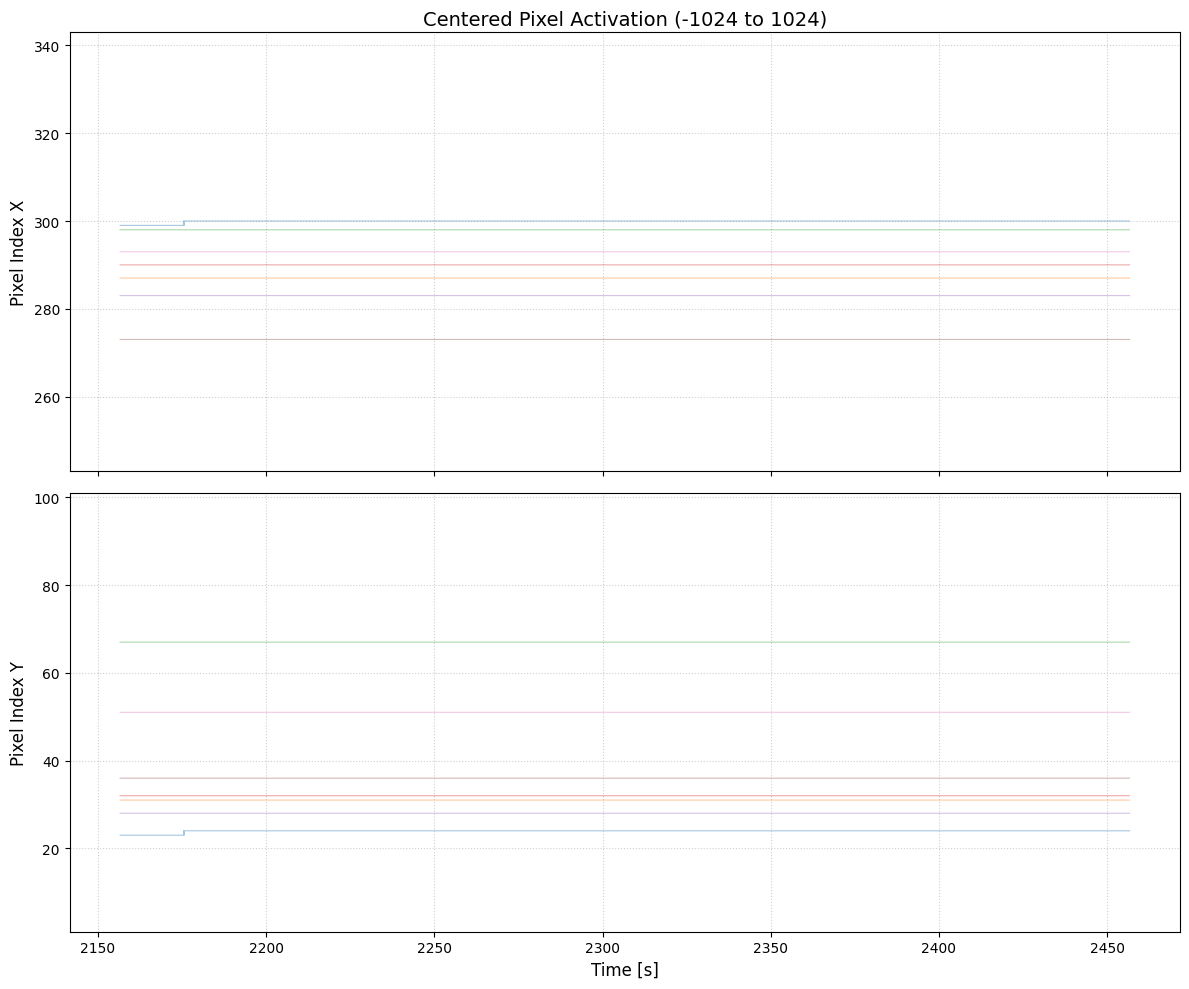

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Constants
num_pixels = 2048
pixel_size = 2.5e-6  # [m]
half_pixels = num_pixels // 2  # 1024

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

#for run_idx in range(len(all_point_on_det_plane)):
for run_idx in [1]:
    # 1. Windowing Logic (as before)
    t_full = full_times[run_idx]
    p_full = phase[run_idx]
    is_fine_phase = (p_full == "Fine Observation") | (p_full == b"Fine Observation")
    
    if not np.any(is_fine_phase):
        continue
    
    t_start, t_end = t_full[is_fine_phase].min(), t_full[is_fine_phase].max()
    t_eng = eng_times[run_idx]
    fine_mask = (t_eng >= t_start) & (t_eng <= t_end)
    
    if not np.any(fine_mask):
        continue
        
    t_plot = t_eng[fine_mask]
    segments = all_point_on_det_plane[run_idx]

    for seg_idx, det_data in enumerate(segments):
        det_plot = det_data[fine_mask] 
        
        # --- Centered Pixel Calculation ---
        # We divide by pixel size and use fix/floor to discretize.
        # np.floor ensures that 0 to 2.5e-6 is Pixel 0, and -2.5e-6 to 0 is Pixel -1.
        pix_x = np.floor(det_plot[:, 0] / pixel_size)
        pix_y = np.floor(det_plot[:, 1] / pixel_size)
        
        # Optional: Clamp to your specific -1024 to 1024 range
        pix_x = np.clip(pix_x, -half_pixels, half_pixels)
        pix_y = np.clip(pix_y, -half_pixels, half_pixels)

        # Plot using step to show discrete pixel jumps
        ax1.step(t_plot, pix_x, alpha=0.4, linewidth=0.8, where='post')
        ax2.step(t_plot, pix_y, alpha=0.4, linewidth=0.8, where='post')

xmean = np.mean(pix_x)
ymean = np.mean(pix_y)

# Aesthetics and Labels
ax1.set_title("Centered Pixel Activation (-1024 to 1024)", fontsize=14)
ax1.set_ylabel("Pixel Index X", fontsize=12)
ax1.set_ylim(xmean - 50, xmean + 50) # Buffer for visibility
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.axhline(0, color='black', lw=1, ls='--') # Zero-center line

ax2.set_ylabel("Pixel Index Y", fontsize=12)
ax2.set_xlabel("Time [s]", fontsize=12)
ax2.set_ylim(ymean - 50, ymean + 50)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.axhline(0, color='black', lw=1, ls='--')

plt.tight_layout()
plt.show()

/tmp/SLURM_7787796/ipykernel_2173186/1141451239.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_matrix = rms_2d_mag_t.applymap(lambda x: f"{x:.2f}")


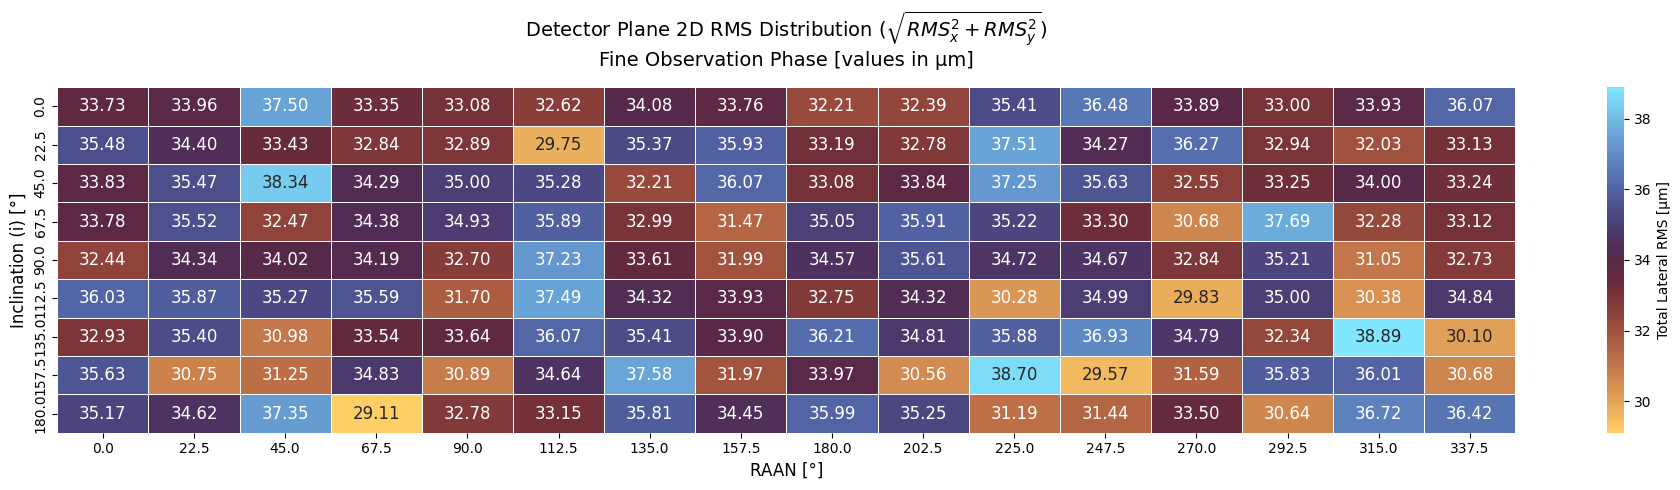

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Calculate the 2D RMS (Magnitude) from your existing tables ---
# We use the Pythagorean theorem on the X and Y RMS values 
# to get the total lateral displacement on the detector plane.
rms_2d_mag = np.sqrt(rms_x_table**2 + rms_y_table**2)

# --- 2. Transpose for the desired orientation ---
# As per your previous preference: Inclination on Y, RAAN on X
rms_2d_mag_t = rms_2d_mag.T

# --- 3. Create the annotation matrix ---
# This will show the RMS value with 2 decimal places in each cell
annot_matrix = rms_2d_mag_t.applymap(lambda x: f"{x:.2f}")

# --- 4. Plotting the Heatmap ---
plt.figure(figsize=(19, 5))

sns.heatmap(
    rms_2d_mag_t, 
    annot=annot_matrix, 
    fmt="", 
    cmap="managua",          # High-contrast sequential colormap
    linewidths=0.5, 
    linecolor='white',      # Sharp grid borders
    cbar_kws={'label': 'Total Lateral RMS [μm]'},
    annot_kws={"fontsize": 12}
)

# --- 5. Labels and Titles ---
plt.title(
    r'Detector Plane 2D RMS Distribution ($\sqrt{RMS_x^2 + RMS_y^2}$)' + 
    '\n' + 'Fine Observation Phase [values in μm]', 
    pad=15, 
    fontsize=14
)

plt.ylabel('Inclination (i) [°]', fontsize=12)
plt.xlabel('RAAN [°]', fontsize=12)

# Save and Show
plt.tight_layout()
plt.savefig('sphere_figs/detector_2d_rms_heatmap.png', dpi=300)
plt.show()

/tmp/SLURM_7787796/ipykernel_2173186/373813780.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_matrix_pix = rms_2d_pix_t.applymap(lambda x: f"{x:.3f}")


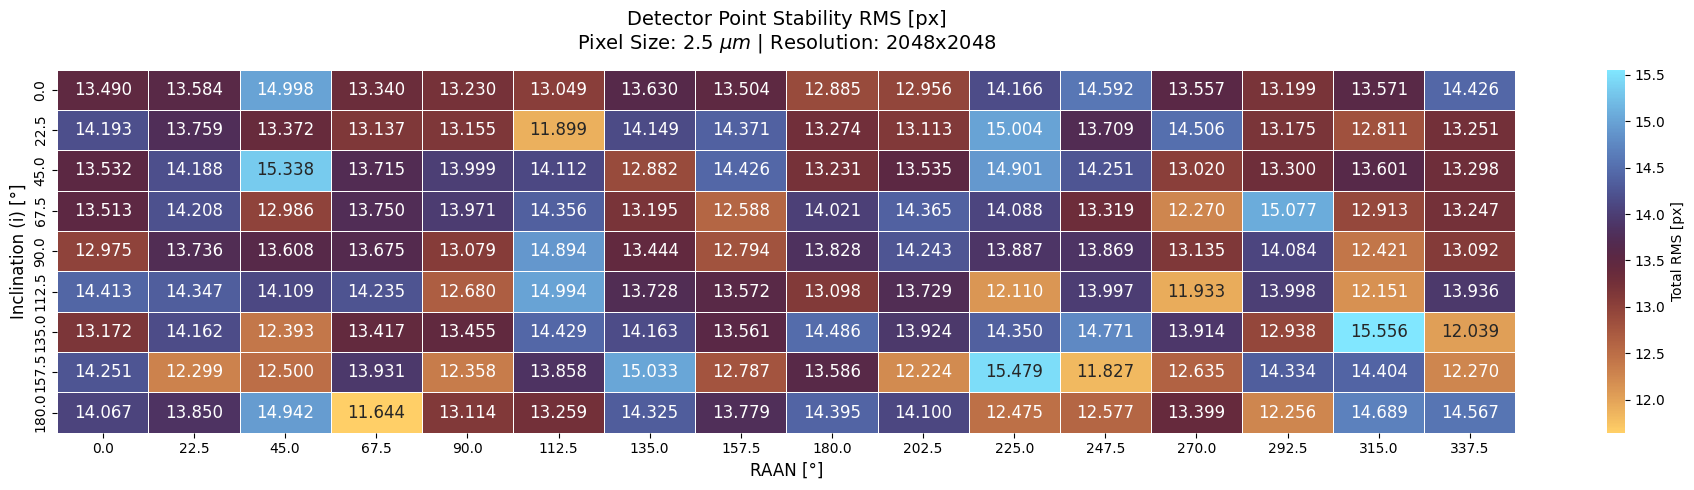

Metric RMS [px]
Min 11.644474306852786
Max 15.555950460197643
Mean 13.611075469510958
Std Dev 0.813884395952953
Peak-to-Valley 3.911476153344857


In [12]:
# --- 1. Constants (from your earlier setup) ---
pixel_size_um = 2.5  # 2.5e-6 m is 2.5 μm

# --- 2. Calculate RMS in Pixels ---
# Your rms_x_table and rms_y_table are already scaled by 1e6 (μm)
# We divide by the pixel size (also in μm) to get the pixel count
rms_x_pix = rms_x_table / pixel_size_um
rms_y_pix = rms_y_table / pixel_size_um

# Pythagorean magnitude in pixel units
rms_2d_pix = np.sqrt(rms_x_pix**2 + rms_y_pix**2)

# --- 3. Transpose for Orientation ---
rms_2d_pix_t = rms_2d_pix.T

# --- 4. Annotation Matrix (Editing Significant Figures here) ---
# Using 3 decimal places to see sub-pixel movement clearly
annot_matrix_pix = rms_2d_pix_t.applymap(lambda x: f"{x:.3f}")

# --- 5. Plotting ---
plt.figure(figsize=(19, 5))

sns.heatmap(
    rms_2d_pix_t, 
    annot=annot_matrix_pix, 
    fmt="", 
    cmap="managua",        # Viridis is often better for "count" based data
    linewidths=0.5, 
    linecolor='white',
    cbar_kws={'label': 'Total RMS [px]'},
    annot_kws={"fontsize": 12}
)

# --- 6. Labels and Titles ---
plt.title(
    r'Detector Point Stability RMS [px]' + 
    '\n' + f'Pixel Size: {pixel_size_um} $\mu m$ | Resolution: 2048x2048', 
    pad=15, 
    fontsize=14
)

plt.ylabel('Inclination (i) [°]', fontsize=12)
plt.xlabel('RAAN [°]', fontsize=12)

plt.tight_layout()
plt.savefig('sphere_figs/detector_pixel_rms_heatmap.png', dpi=300)
plt.show()


def get_stats(df, name):
    stats = {
        'Metric': name,
        'Min': df.values.min(),
        'Max': df.values.max(),
        'Mean': df.values.mean(),
        'Std Dev': df.values.std(),
        'Peak-to-Valley': df.values.max() - df.values.min()
        }
    return stats
    
print(30*'=')
rho = get_stats(rms_2d_pix, r"RMS [px]")
for entry in rho:
    print(entry, rho[entry])
print(30*'=')

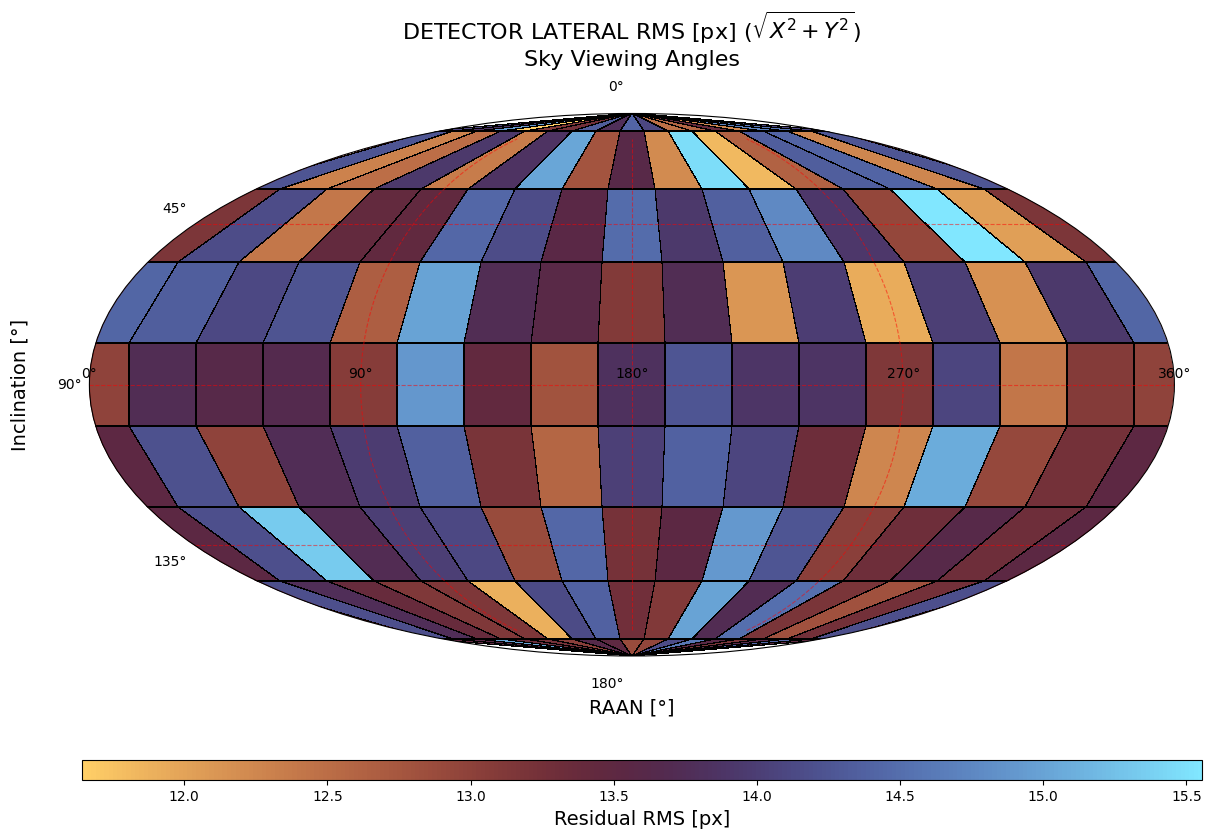

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# ==========================================
# 1. HELPER FUNCTIONS
# ==========================================
def get_data_relative_edges(centers):
    """Calculates edges strictly around provided centers for pcolormesh."""
    centers = np.sort(np.asarray(centers, dtype=float))
    if len(centers) < 2:
        return np.array([centers[0] - 0.5, centers[0] + 0.5])
        
    mids = 0.5 * (centers[:-1] + centers[1:])
    step = np.mean(np.diff(centers))
    
    first = centers[0] - step/2
    last = centers[-1] + step/2
    
    return np.concatenate([[first], mids, [last]])

def plot_mollweide_detector_rms(ax, df, title, norm, cmap="managua"):
    # 1. Prepare Data & Handle RAAN wrap for a closed ellipse
    df_plot = df.copy()
    if 360.0 not in df_plot.index and 0.0 in df_plot.index:
        df_plot.loc[360.0] = df_plot.loc[0.0]
    
    # 2. Coordinate Mapping
    # RAAN (0 to 360) -> Lon (-180 to 180)
    raan_centers = df_plot.index.to_numpy(dtype=float)
    lon_centers = raan_centers - 180.0
    
    # Inclination (0 to 180) -> Lat (90 to -90)
    # i=0 is North Pole (+90), i=180 is South Pole (-90)
    inc_centers = df_plot.columns.to_numpy(dtype=float)
    lat_centers = 90.0 - inc_centers
    
    # 3. Create Edges (Ensures poles are split by RAAN)
    lon_edges = np.deg2rad(get_data_relative_edges(lon_centers))
    lat_edges = np.deg2rad(get_data_relative_edges(lat_centers))
    
    # Safety clip for polar boundaries
    lat_edges = np.clip(lat_edges, -np.pi/2, np.pi/2)
    
    # 4. Plotting
    Z = df_plot.to_numpy().T 
    mesh = ax.pcolormesh(
        lon_edges, lat_edges, Z,
        norm=norm, cmap=cmap,
        edgecolors='k', linewidth=0.1,
        shading='flat'
    )
    
    # 5. Styling
    ax.set_title(title, pad=35, fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.5, color='red')
    
    # Custom Ticks to match simulation params
    ax.set_xticks(np.deg2rad([-180, -90, 0, 90, 180]))
    ax.set_xticklabels(['0°', '90°', '180°', '270°', '360°'])
    ax.set_yticks(np.deg2rad([90, 45, 0, -45, -90]))
    ax.set_yticklabels(['0°', '45°', '90°', '135°', '180°'])
    
    return mesh

# ==========================================
# 2. EXECUTION
# ==========================================

# 2.1 Calculate Lateral RMS in Pixels (Pixel Size = 2.5 um)
pixel_size = 2.5
rms_lateral_pix = np.sqrt((rms_x_table/pixel_size)**2 + (rms_y_table/pixel_size)**2)

# 2.2 Setup Single Plot
fig = plt.figure(figsize=(14, 10), facecolor='white')
ax = fig.add_subplot(111, projection='mollweide')

# 2.3 Color Scale
norm = Normalize(vmin=rms_lateral_pix.min().min(), vmax=rms_lateral_pix.max().max())

# 2.4 Generate Plot
m = plot_mollweide_detector_rms(
    ax, 
    rms_lateral_pix, 
    r"DETECTOR LATERAL RMS [px] ($\sqrt{X^2 + Y^2}$)" + "\n" + "Sky Viewing Angles", 
    norm,
    cmap = 'managua'
)

# 2.5 Labels and Colorbar
ax.set_xlabel("RAAN [°]", fontsize=14, labelpad=30)
ax.set_ylabel("Inclination [°]", fontsize=14, labelpad=20)

# Centered colorbar at the bottom
cax = fig.add_axes([0.12, 0.1, 0.8, 0.02])
cb = fig.colorbar(m, cax=cax, orientation="horizontal")
cb.set_label("Residual RMS [px]", fontsize=14)

plt.savefig('sphere_figs/mollweide_lateral_pixel_rms.png', dpi=300, bbox_inches='tight')
plt.show()